## Detector performance analysis

This section generates four summary plots from the simulation CSV outputs:
1. detection efficiency by emitter isotope
2. source attribution by detector face
3. photon path class through water, glue, and detector
4. detector entry-position heatmaps

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

build_dir = Path('./PhotonDetector/build')
dataset_stem = '2mm_50um_bottom_1k'  # switch to '2mm_2mm_1k' or another available stem as needed
macro_path = build_dir / 'pos.mac'  # optional: point this at the macro used for the selected dataset
detector_construction_path = Path('./PhotonDetector/src/DetectorConstruction.cc')

photon_path = build_dir / f'{dataset_stem}_photon_boundaries.csv'
rn_path = build_dir / f'{dataset_stem}_Rn222_exit_glue_events.csv'

unit_to_mm = {'mm': 1.0, 'cm': 10.0, 'm': 1000.0, 'um': 1e-3}

def parse_length_expression(source_text, variable_name):
    pattern = rf"{variable_name}\s*=\s*([0-9.]+)\s*\*\s*(mm|cm|m|um)"
    match = re.search(pattern, source_text)
    if not match:
        raise ValueError(f'Could not parse {variable_name} from {detector_construction_path}')
    value, unit = match.groups()
    return float(value) * unit_to_mm[unit]

def parse_macro_override(path, command_name):
    if path is None or not Path(path).exists():
        return None
    pattern = rf"^\s*{re.escape(command_name)}\s+([0-9.]+)\s+(mm|cm|m|um)\s*$"
    for line in Path(path).read_text().splitlines():
        match = re.match(pattern, line)
        if match:
            value, unit = match.groups()
            return float(value) * unit_to_mm[unit]
    return None

detector_construction_source = detector_construction_path.read_text()
x_water_half_mm = parse_length_expression(detector_construction_source, 'xWater')
y_water_half_mm = parse_length_expression(detector_construction_source, 'yWater')
z_water_half_mm = parse_length_expression(detector_construction_source, 'zWater')
detector_padding_mm = parse_length_expression(detector_construction_source, 'detectorPadding')

macro_detector_padding_mm = parse_macro_override(macro_path, '/det/set_detectorPadding')
if macro_detector_padding_mm is not None:
    detector_padding_mm = macro_detector_padding_mm

detector_half_spans_mm = {
    'x': x_water_half_mm + detector_padding_mm,
    'y': y_water_half_mm + detector_padding_mm,
    'z': z_water_half_mm + detector_padding_mm,
}

df = pd.read_csv(photon_path)
rn_df = pd.read_csv(rn_path)

gamma_df = df[df['particleName'] == 'gamma'].copy()
gamma_df['is_detector'] = gamma_df['volumeName'].str.startswith('physPhotonDetector')
gamma_df['detector_face'] = gamma_df['volumeName'].where(gamma_df['is_detector'], 'not_detector')

event_track_cols = ['eventID', 'trackID']
gamma_tracks = gamma_df[event_track_cols + ['originIsotope']].drop_duplicates()
detected_tracks = (
    gamma_df[(gamma_df['boundary'] == 'enter') & gamma_df['is_detector']]
    [event_track_cols + ['originIsotope', 'detector_face']]
    .drop_duplicates(event_track_cols)
)

gamma_df = gamma_df.reset_index(names='row_order')

def simplify_volume(volume_name):
    if volume_name.startswith('physPhotonDetector'):
        return 'detector'
    if volume_name == 'physWater':
        return 'water'
    if volume_name == 'physGlue':
        return 'glue'
    return volume_name

def reconstruct_track_path(track_df):
    ordered = track_df.sort_values(['time_s', 'row_order']).copy()
    visited = []
    transitions = []

    def append_volume(volume_name):
        simplified = simplify_volume(volume_name)
        if not visited or visited[-1] != simplified:
            visited.append(simplified)

    rows = list(ordered.itertuples(index=False))
    if rows and rows[0].boundary == 'exit':
        append_volume(rows[0].volumeName)

    for row in rows:
        transitions.append(f"{row.boundary} {row.volumeName}")
        if row.boundary == 'enter':
            append_volume(row.volumeName)

    return pd.Series({
        'originIsotope': ordered['originIsotope'].iloc[0],
        'path_sequence': tuple(visited),
        'transition_sequence': tuple(transitions),
        'detector_face': next((v for v in ordered['detector_face'] if v != 'not_detector'), np.nan),
        'kineticEnergy_MeV': ordered['kineticEnergy_MeV'].max(),
    })

path_summary = gamma_df.groupby(event_track_cols, sort=False).apply(reconstruct_track_path, include_groups=False).reset_index()
path_summary['path_class'] = path_summary['path_sequence'].apply(lambda seq: ' -> '.join(seq) if seq else 'other')

detector_entries = gamma_df[(gamma_df['boundary'] == 'enter') & gamma_df['is_detector']].copy()

detector_normal_component = {
    'physPhotonDetectorPosX': 'px',
    'physPhotonDetectorNegX': 'px',
    'physPhotonDetectorPosY': 'py',
    'physPhotonDetectorNegY': 'py',
    'physPhotonDetectorPosZ': 'pz',
    'physPhotonDetectorNegZ': 'pz',
}
detector_entries['normal_component'] = detector_entries.apply(
    lambda row: abs(row[detector_normal_component[row['volumeName']]]),
    axis=1,
)
detector_entries['normal_component'] = detector_entries['normal_component'].clip(0.0, 1.0)
detector_entries['incidence_angle_deg'] = np.degrees(np.arccos(detector_entries['normal_component']))

print(f'Using dataset: {dataset_stem}')
print(f'Geometry source: {detector_construction_path}')
print(f'Macro override file: {macro_path if Path(macro_path).exists() else "none"}')
print(f'Detector padding used in analysis: {detector_padding_mm:.3f} mm')
print(f'Photon boundary rows: {len(gamma_df):,}')
print(f'Unique gamma tracks: {len(gamma_tracks):,}')
print(f'Detected gamma tracks: {detected_tracks[event_track_cols].drop_duplicates().shape[0]:,}')
print(f'Rn222 glue-exit events: {len(rn_df):,}')

Using dataset: 2mm_50um_bottom_1k
Geometry source: PhotonDetector/src/DetectorConstruction.cc
Macro override file: none
Detector padding used in analysis: 50.000 mm
Photon boundary rows: 4,098
Unique gamma tracks: 1,668
Detected gamma tracks: 1,363
Rn222 glue-exit events: 550


,emitted,detected,efficiency
originIsotope,,,
Po214,975,813,0.833846
Bi214,638,523,0.819749
Bi210,54,27,0.500000
Pb214,1,0,0.000000


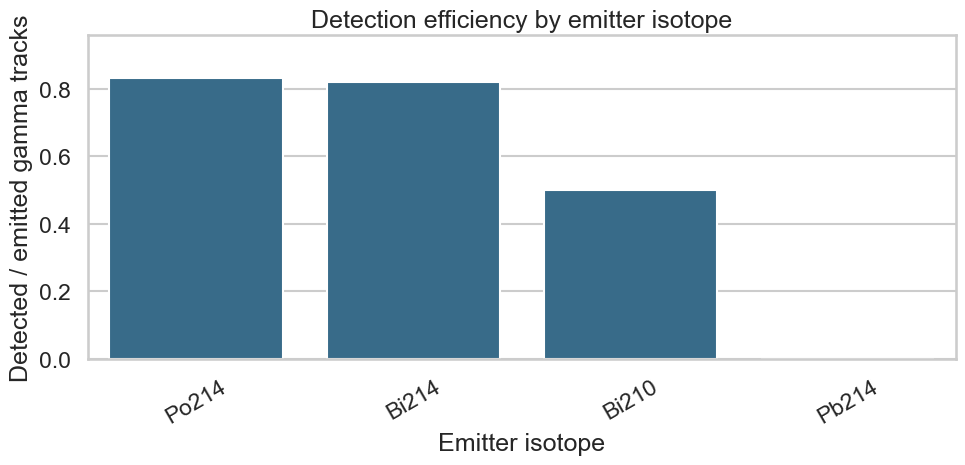

In [2]:
# 1. Detection efficiency by emitter isotope
emitted_counts = gamma_tracks.groupby('originIsotope').size().rename('emitted')
detected_counts = detected_tracks.groupby('originIsotope').size().rename('detected')
efficiency = (
    pd.concat([emitted_counts, detected_counts], axis=1)
    .fillna(0)
    .assign(detected=lambda x: x['detected'].astype(int), efficiency=lambda x: x['detected'] / x['emitted'])
    .sort_values('efficiency', ascending=False)
)

display(efficiency)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=efficiency.reset_index(), x='originIsotope', y='efficiency', color='#2a6f97', ax=ax)
ax.set_title('Detection efficiency by emitter isotope')
ax.set_xlabel('Emitter isotope')
ax.set_ylabel('Detected / emitted gamma tracks')
ax.set_ylim(0, min(1.0, efficiency['efficiency'].max() * 1.15))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

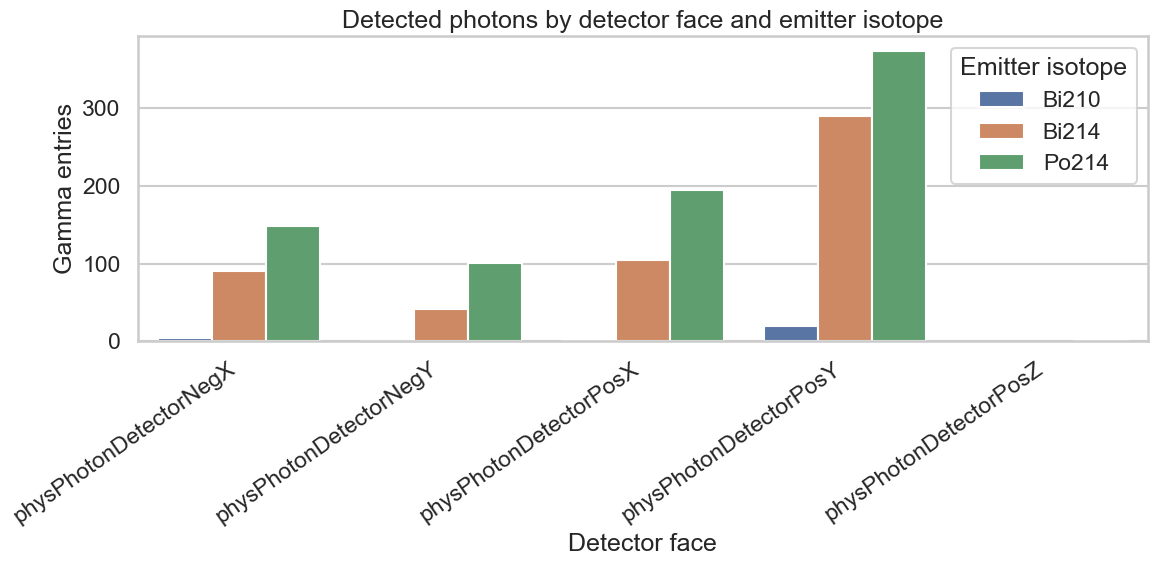

In [3]:
# 2. Source attribution by detector face
face_counts = (
    detector_entries.groupby(['originIsotope', 'volumeName'])
    .size()
    .rename('count')
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=face_counts, x='volumeName', y='count', hue='originIsotope')
plt.title('Detected photons by detector face and emitter isotope')
plt.xlabel('Detector face')
plt.ylabel('Gamma entries')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Emitter isotope')
plt.tight_layout()
plt.show()

,path_class,count
0,detector,1015
1,glue -> detector,236
2,glue,196
3,water,97
4,water -> detector,94
5,glue -> water,7
6,water -> glue -> detector,6
7,water -> glue,4
8,detector -> water,4
9,detector -> water -> detector,3


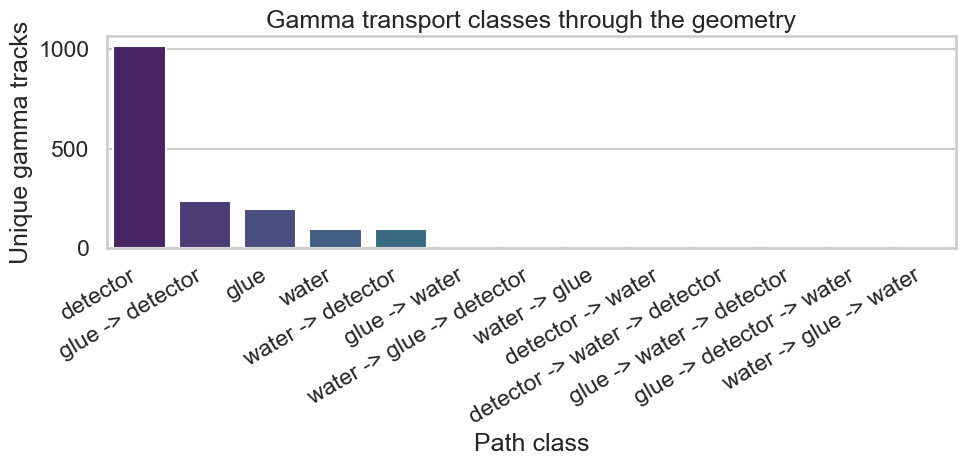

In [4]:
# 3. Penetration and transport path classes
path_counts = (
    path_summary['path_class']
    .value_counts()
    .rename_axis('path_class')
    .reset_index(name='count')
)

display(path_counts)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=path_counts, x='path_class', y='count', hue='path_class', palette='viridis', legend=False, ax=ax)
ax.set_title('Gamma transport classes through the geometry')
ax.set_xlabel('Path class')
ax.set_ylabel('Unique gamma tracks')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

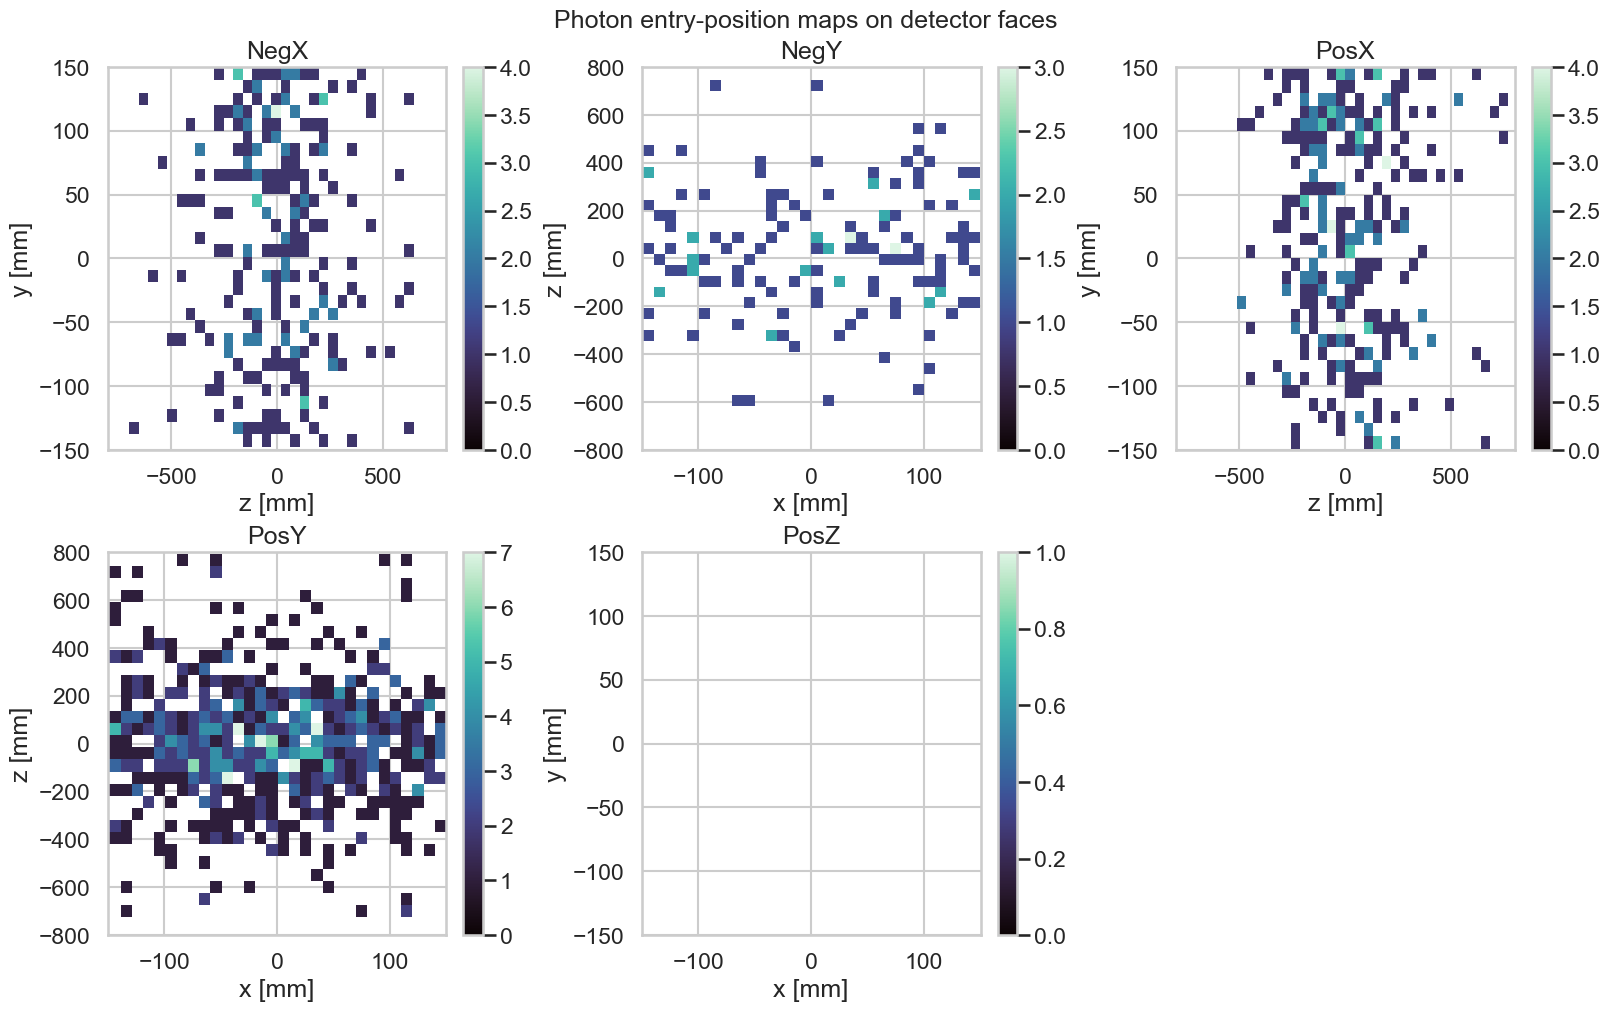

In [5]:
# 4. Detector entry-position heatmaps
faces = sorted(detector_entries['volumeName'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.flatten()

face_axes = {
    'physPhotonDetectorPosX': ('z_mm', 'y_mm'),
    'physPhotonDetectorNegX': ('z_mm', 'y_mm'),
    'physPhotonDetectorPosY': ('x_mm', 'z_mm'),
    'physPhotonDetectorNegY': ('x_mm', 'z_mm'),
    'physPhotonDetectorPosZ': ('x_mm', 'y_mm'),
    'physPhotonDetectorNegZ': ('x_mm', 'y_mm'),
}
face_limits = {
    'physPhotonDetectorPosX': ((-detector_half_spans_mm['z'], detector_half_spans_mm['z']), (-detector_half_spans_mm['y'], detector_half_spans_mm['y'])),
    'physPhotonDetectorNegX': ((-detector_half_spans_mm['z'], detector_half_spans_mm['z']), (-detector_half_spans_mm['y'], detector_half_spans_mm['y'])),
    'physPhotonDetectorPosY': ((-detector_half_spans_mm['x'], detector_half_spans_mm['x']), (-detector_half_spans_mm['z'], detector_half_spans_mm['z'])),
    'physPhotonDetectorNegY': ((-detector_half_spans_mm['x'], detector_half_spans_mm['x']), (-detector_half_spans_mm['z'], detector_half_spans_mm['z'])),
    'physPhotonDetectorPosZ': ((-detector_half_spans_mm['x'], detector_half_spans_mm['x']), (-detector_half_spans_mm['y'], detector_half_spans_mm['y'])),
    'physPhotonDetectorNegZ': ((-detector_half_spans_mm['x'], detector_half_spans_mm['x']), (-detector_half_spans_mm['y'], detector_half_spans_mm['y'])),
}

for ax, face in zip(axes, faces):
    face_df = detector_entries[detector_entries['volumeName'] == face]
    xcol, ycol = face_axes[face]
    sns.histplot(face_df, x=xcol, y=ycol, bins=30, cmap='mako', cbar=True, ax=ax)
    xlim, ylim = face_limits[face]
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_title(face.replace('physPhotonDetector', ''))
    ax.set_xlabel(xcol.replace('_mm', ' [mm]'))
    ax.set_ylabel(ycol.replace('_mm', ' [mm]'))

for ax in axes[len(faces):]:
    ax.axis('off')

fig.suptitle('Photon entry-position maps on detector faces', fontsize=18)
plt.show()

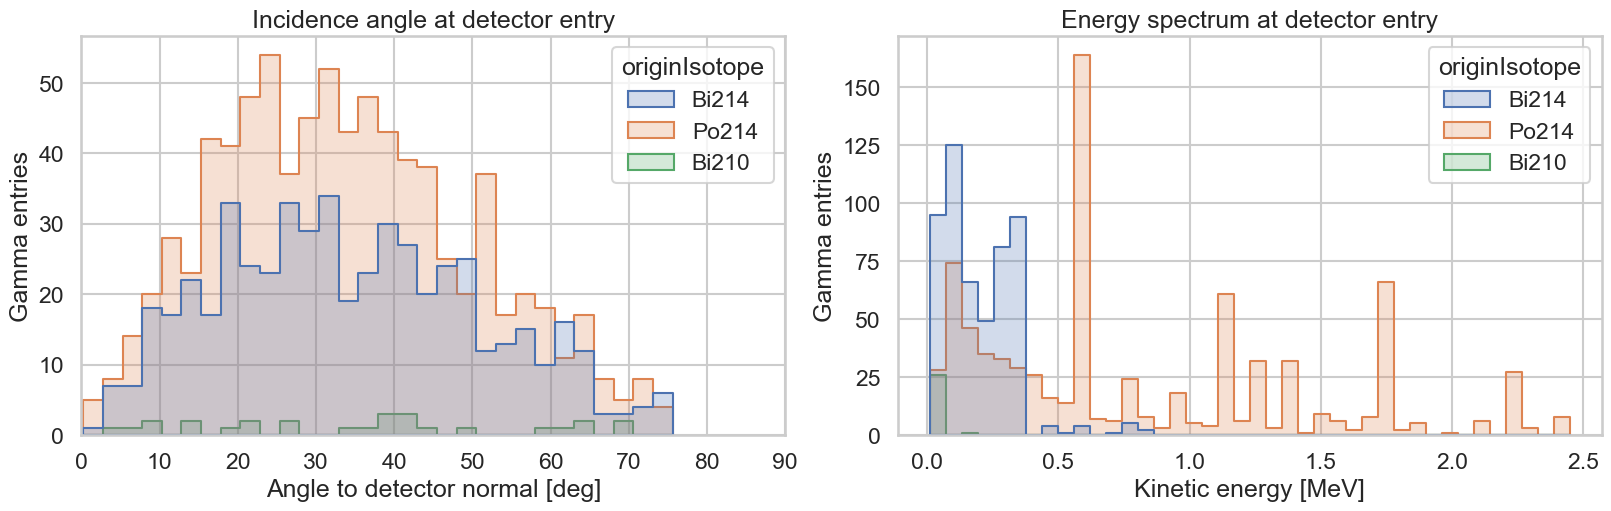

In [6]:
# 5. Detector-entry incidence angle and energy spectra
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

sns.histplot(
    detector_entries,
    x='incidence_angle_deg',
    hue='originIsotope',
    bins=30,
    element='step',
    stat='count',
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title('Incidence angle at detector entry')
axes[0].set_xlabel('Angle to detector normal [deg]')
axes[0].set_ylabel('Gamma entries')
axes[0].set_xlim(0, 90)

sns.histplot(
    detector_entries,
    x='kineticEnergy_MeV',
    hue='originIsotope',
    bins=40,
    element='step',
    stat='count',
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title('Energy spectrum at detector entry')
axes[1].set_xlabel('Kinetic energy [MeV]')
axes[1].set_ylabel('Gamma entries')

plt.show()

## Gamma back-projection into the water box

A single detected gamma gives a source track rather than a unique source point. As a first-pass reconstruction, this section projects each detector hit backwards along `-momentum` and intersects that track with the water box. It stores two point estimates: the point where the back-projected track enters the water box, and the midpoint of the track segment inside the water box.

Energy is retained for filtering and diagnostics, but this straight-line reconstruction is geometric. It assumes the detected momentum still points back to the emitter, so scattered gammas should be treated as lower-confidence reconstructions.

In [7]:
# 6. Estimate water-box source-track positions, preferring logged water boundaries
water_bounds_mm = np.array([
    [-x_water_half_mm, x_water_half_mm],
    [-y_water_half_mm, y_water_half_mm],
    [-z_water_half_mm, z_water_half_mm],
], dtype=float)

water_boundary_rows = gamma_df[gamma_df['volumeName'] == 'physWater'].copy()

water_logged_summary = (
    water_boundary_rows.sort_values(['eventID', 'trackID', 'time_s', 'row_order'])
    .groupby(event_track_cols, sort=False)
    .agg(
        logged_water_boundary_count=('boundary', 'size'),
        logged_water_entry_x_mm=('x_mm', 'first'),
        logged_water_entry_y_mm=('y_mm', 'first'),
        logged_water_entry_z_mm=('z_mm', 'first'),
        logged_water_exit_x_mm=('x_mm', 'last'),
        logged_water_exit_y_mm=('y_mm', 'last'),
        logged_water_exit_z_mm=('z_mm', 'last'),
    )
    .reset_index()
)

logged_entry = water_logged_summary[['logged_water_entry_x_mm', 'logged_water_entry_y_mm', 'logged_water_entry_z_mm']].to_numpy()
logged_exit = water_logged_summary[['logged_water_exit_x_mm', 'logged_water_exit_y_mm', 'logged_water_exit_z_mm']].to_numpy()
water_logged_summary['logged_water_path_length_mm'] = np.linalg.norm(logged_exit - logged_entry, axis=1)
water_logged_summary['logged_mid_x_mm'] = 0.5 * (water_logged_summary['logged_water_entry_x_mm'] + water_logged_summary['logged_water_exit_x_mm'])
water_logged_summary['logged_mid_y_mm'] = 0.5 * (water_logged_summary['logged_water_entry_y_mm'] + water_logged_summary['logged_water_exit_y_mm'])
water_logged_summary['logged_mid_z_mm'] = 0.5 * (water_logged_summary['logged_water_entry_z_mm'] + water_logged_summary['logged_water_exit_z_mm'])

def track_box_intersection(origin, direction, bounds, eps=1e-12):
    t_near = -np.inf
    t_far = np.inf

    for axis in range(3):
        low, high = bounds[axis]
        if abs(direction[axis]) < eps:
            if origin[axis] < low or origin[axis] > high:
                return None
            continue

        t1 = (low - origin[axis]) / direction[axis]
        t2 = (high - origin[axis]) / direction[axis]
        t_axis_near = min(t1, t2)
        t_axis_far = max(t1, t2)
        t_near = max(t_near, t_axis_near)
        t_far = min(t_far, t_axis_far)

    if t_far < max(t_near, 0.0):
        return None

    t_entry = max(t_near, 0.0)
    t_exit = t_far
    return t_entry, t_exit

def reconstruct_water_segment(row):
    hit = np.array([row['x_mm'], row['y_mm'], row['z_mm']], dtype=float)
    momentum = np.array([row['px'], row['py'], row['pz']], dtype=float)
    norm = np.linalg.norm(momentum)

    if norm == 0 or not np.isfinite(norm):
        return pd.Series({'backproject_intersects_water': False})

    direction = -momentum / norm
    no_intersection_payload = {
        'backproject_intersects_water': False,
        'track_origin_x_mm': hit[0],
        'track_origin_y_mm': hit[1],
        'track_origin_z_mm': hit[2],
        'track_dir_x': direction[0],
        'track_dir_y': direction[1],
        'track_dir_z': direction[2],
    }
    interval = track_box_intersection(hit, direction, water_bounds_mm)
    if interval is None:
        return pd.Series(no_intersection_payload)

    t_entry, t_exit = interval
    entry = hit + t_entry * direction
    exit_point = hit + t_exit * direction
    midpoint = 0.5 * (entry + exit_point)

    return pd.Series({
        'backproject_intersects_water': True,
        'track_origin_x_mm': hit[0],
        'track_origin_y_mm': hit[1],
        'track_origin_z_mm': hit[2],
        'track_dir_x': direction[0],
        'track_dir_y': direction[1],
        'track_dir_z': direction[2],
        'backproject_t_entry_mm': t_entry,
        'backproject_t_exit_mm': t_exit,
        'backproject_water_path_length_mm': t_exit - t_entry,
        'backproject_entry_x_mm': entry[0],
        'backproject_entry_y_mm': entry[1],
        'backproject_entry_z_mm': entry[2],
        'backproject_exit_x_mm': exit_point[0],
        'backproject_exit_y_mm': exit_point[1],
        'backproject_exit_z_mm': exit_point[2],
        'backproject_mid_x_mm': midpoint[0],
        'backproject_mid_y_mm': midpoint[1],
        'backproject_mid_z_mm': midpoint[2],
    })

backproject_results = detector_entries.apply(reconstruct_water_segment, axis=1).reset_index(drop=True)
backproject_df = pd.concat(
    [detector_entries.reset_index(drop=True), backproject_results],
    axis=1,
)
backproject_df['backproject_intersects_water'] = backproject_df['backproject_intersects_water'].where(
    backproject_df['backproject_intersects_water'].notna(), False
).astype(bool)

reco_df = backproject_df.merge(water_logged_summary, on=event_track_cols, how='left')
reco_df['has_logged_water_boundary'] = reco_df['logged_water_boundary_count'].notna()
reco_df['reco_method'] = np.select(
    [reco_df['has_logged_water_boundary'], reco_df['backproject_intersects_water']],
    ['logged_water_boundary', 'backprojected_detector_track'],
    default='no_water_intersection',
)
reco_df['reco_intersects_water'] = reco_df['reco_method'] != 'no_water_intersection'

logged_cols = {
    'reco_entry_x_mm': 'logged_water_entry_x_mm',
    'reco_entry_y_mm': 'logged_water_entry_y_mm',
    'reco_entry_z_mm': 'logged_water_entry_z_mm',
    'reco_exit_x_mm': 'logged_water_exit_x_mm',
    'reco_exit_y_mm': 'logged_water_exit_y_mm',
    'reco_exit_z_mm': 'logged_water_exit_z_mm',
    'reco_mid_x_mm': 'logged_mid_x_mm',
    'reco_mid_y_mm': 'logged_mid_y_mm',
    'reco_mid_z_mm': 'logged_mid_z_mm',
    'reco_water_path_length_mm': 'logged_water_path_length_mm',
}
backproject_cols = {target: target.replace('reco_', 'backproject_') for target in logged_cols}

for target_col, logged_col in logged_cols.items():
    backproject_col = backproject_cols[target_col]
    reco_df[target_col] = np.where(
        reco_df['has_logged_water_boundary'],
        reco_df[logged_col],
        reco_df[backproject_col],
    )

reco_water_df = reco_df[reco_df['reco_intersects_water']].copy()

print(f'Detector entries: {len(reco_df):,}')
print(f'Detector entries with logged water boundaries: {reco_df["has_logged_water_boundary"].sum():,}')
print(f'Detector entries using back-projected water intersections: {(reco_df["reco_method"] == "backprojected_detector_track").sum():,}')
print(f'Detector entries with no water estimate: {(reco_df["reco_method"] == "no_water_intersection").sum():,}')
display(reco_df['reco_method'].value_counts().rename_axis('reco_method').reset_index(name='count'))
display(reco_water_df[[
    'eventID', 'trackID', 'originIsotope', 'volumeName', 'reco_method', 'kineticEnergy_MeV', 'incidence_angle_deg',
    'reco_water_path_length_mm', 'reco_entry_x_mm', 'reco_entry_y_mm', 'reco_entry_z_mm',
    'reco_mid_x_mm', 'reco_mid_y_mm', 'reco_mid_z_mm'
]].head())

Detector entries: 1,372
Detector entries with logged water boundaries: 118
Detector entries using back-projected water intersections: 1,241
Detector entries with no water estimate: 13


,reco_method,count
0,backprojected_detector_track,1241
1,logged_water_boundary,118
2,no_water_intersection,13


,eventID,trackID,originIsotope,volumeName,reco_method,kineticEnergy_MeV,incidence_angle_deg,reco_water_path_length_mm,reco_entry_x_mm,reco_entry_y_mm,reco_entry_z_mm,reco_mid_x_mm,reco_mid_y_mm,reco_mid_z_mm
0,0,1475,Bi214,physPhotonDetectorNegX,backprojected_detector_track,0.068670,63.468805,165.361779,-100.000000,81.215898,45.074190,-63.067694,90.607949,-28.301035
1,0,1857,Po214,physPhotonDetectorPosY,backprojected_detector_track,0.768361,21.559105,215.044663,-23.328715,100.000000,2.425232,-40.631323,0.000000,37.945247
2,1,1475,Bi214,physPhotonDetectorPosY,backprojected_detector_track,0.047702,70.917395,556.224061,-10.695821,100.000000,-133.595203,44.652089,9.076554,123.340270
3,2,1752,Po214,physPhotonDetectorPosY,backprojected_detector_track,1.561020,42.764137,272.422104,-30.950841,100.000000,11.667072,-5.650462,0.000000,-77.289892
4,3,1256,Bi214,physPhotonDetectorPosX,backprojected_detector_track,0.351932,18.805024,120.548509,100.000000,67.493969,3.943948,42.943117,83.746985,-6.702054


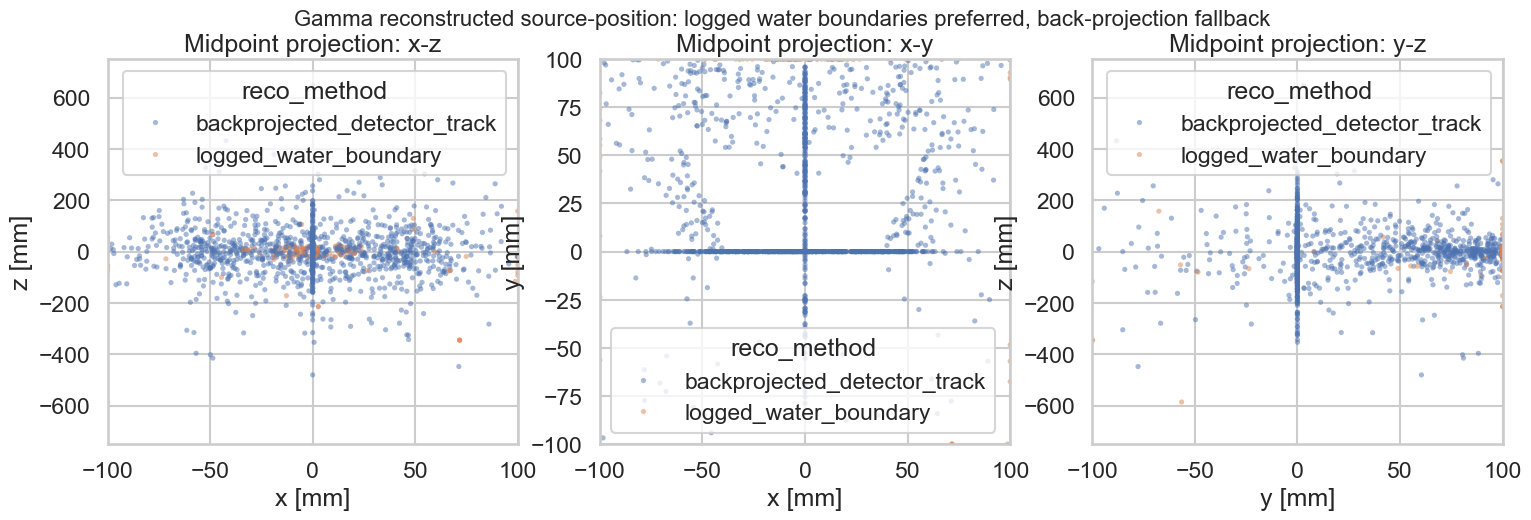

In [8]:
# 7. Visualize source-position proxies in the water box
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=False)

projection_specs = [
    ('reco_mid_x_mm', 'reco_mid_z_mm', (-x_water_half_mm, x_water_half_mm), (-z_water_half_mm, z_water_half_mm), 'x [mm]', 'z [mm]', 'Midpoint projection: x-z'),
    ('reco_mid_x_mm', 'reco_mid_y_mm', (-x_water_half_mm, x_water_half_mm), (-y_water_half_mm, y_water_half_mm), 'x [mm]', 'y [mm]', 'Midpoint projection: x-y'),
    ('reco_mid_y_mm', 'reco_mid_z_mm', (-y_water_half_mm, y_water_half_mm), (-z_water_half_mm, z_water_half_mm), 'y [mm]', 'z [mm]', 'Midpoint projection: y-z'),
]

for ax, (xcol, ycol, xlim, ylim, xlabel, ylabel, title) in zip(axes, projection_specs):
    sns.scatterplot(
        reco_water_df,
        x=xcol,
        y=ycol,
        hue='reco_method',
        s=14,
        alpha=0.5,
        linewidth=0,
        ax=ax
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    #ax.set_aspect('equal')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

fig.suptitle('Gamma reconstructed source-position: logged water boundaries preferred, back-projection fallback', fontsize=16)
plt.show()


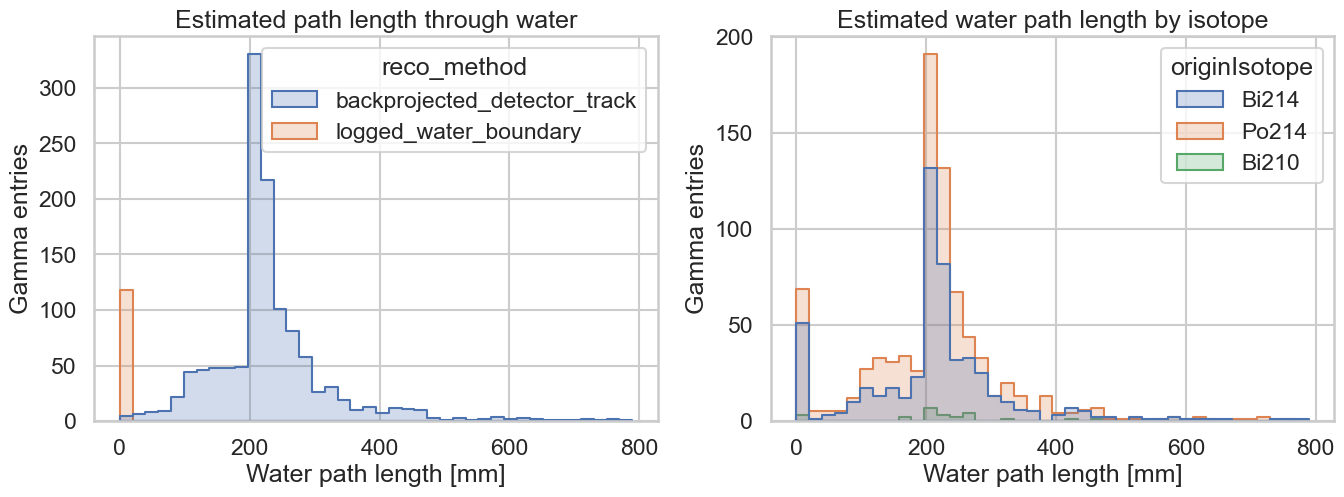

In [9]:

# histograms path length

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=False)
sns.histplot(reco_water_df, x='reco_water_path_length_mm', hue='reco_method', bins=40, element='step', common_norm=False, ax=axes[0])
axes[0].set_title('Estimated path length through water')
axes[0].set_xlabel('Water path length [mm]')
axes[0].set_ylabel('Gamma entries')

sns.histplot(reco_water_df, x='reco_water_path_length_mm', hue='originIsotope', bins=40, element='step', common_norm=False, ax=axes[1])
axes[1].set_title('Estimated water path length by isotope')
axes[1].set_xlabel('Water path length [mm]')
axes[1].set_ylabel('Gamma entries')
plt.show()

In [10]:
# 8. Compare detector back-projection track against emitted gamma truth
inline_truth_cols = {'gammaEmittedX_mm', 'gammaEmittedY_mm', 'gammaEmittedZ_mm'}

if inline_truth_cols.issubset(reco_df.columns):
    reco_truth_df = reco_df.copy()
    reco_truth_df['emitX_mm'] = reco_truth_df['gammaEmittedX_mm']
    reco_truth_df['emitY_mm'] = reco_truth_df['gammaEmittedY_mm']
    reco_truth_df['emitZ_mm'] = reco_truth_df['gammaEmittedZ_mm']
    truth_source = photon_path
elif inline_truth_cols.issubset(gamma_df.columns):
    truth_df = (
        gamma_df[event_track_cols + ['gammaEmittedX_mm', 'gammaEmittedY_mm', 'gammaEmittedZ_mm', 'sourceVolumeName']]
        .drop_duplicates(event_track_cols)
        .rename(columns={
            'gammaEmittedX_mm': 'emitX_mm',
            'gammaEmittedY_mm': 'emitY_mm',
            'gammaEmittedZ_mm': 'emitZ_mm',
        })
    )
    reco_truth_df = reco_df.merge(truth_df, on=event_track_cols, how='inner')
    truth_source = photon_path
else:
    truth_candidate_paths = [
        build_dir / f'{dataset_stem}_gamma_truth.csv',
        build_dir / f'{dataset_stem}_gamma_emissions.csv',
    ]
    truth_path = next((path for path in truth_candidate_paths if path.exists()), None)

    if truth_path is None:
        reco_truth_df = pd.DataFrame()
        truth_source = None
        print('No gamma emission truth found. Expected inline columns or one of:')
        for path in truth_candidate_paths:
            print(f'  {path}')
    else:
        truth_df = pd.read_csv(truth_path)
        required_truth_cols = {'eventID', 'trackID', 'emitX_mm', 'emitY_mm', 'emitZ_mm'}
        missing = required_truth_cols - set(truth_df.columns)
        if missing:
            raise ValueError(f'{truth_path} is missing required columns: {sorted(missing)}')
        optional_cols = ['sourceVolumeName'] if 'sourceVolumeName' in truth_df.columns else []
        reco_truth_df = reco_df.merge(
            truth_df[['eventID', 'trackID', 'emitX_mm', 'emitY_mm', 'emitZ_mm'] + optional_cols],
            on=['eventID', 'trackID'],
            how='inner',
        )
        truth_source = truth_path

if not reco_truth_df.empty:
    track_origin = reco_truth_df[['track_origin_x_mm', 'track_origin_y_mm', 'track_origin_z_mm']].to_numpy(dtype=float)
    track_dir = reco_truth_df[['track_dir_x', 'track_dir_y', 'track_dir_z']].to_numpy(dtype=float)
    truth_pos = reco_truth_df[['emitX_mm', 'emitY_mm', 'emitZ_mm']].to_numpy(dtype=float)
    origin_to_truth = truth_pos - track_origin

    reco_truth_df['truth_track_t_mm'] = np.einsum('ij,ij->i', origin_to_truth, track_dir)
    closest = track_origin + reco_truth_df['truth_track_t_mm'].to_numpy()[:, None] * track_dir
    reco_truth_df['closest_track_x_mm'] = closest[:, 0]
    reco_truth_df['closest_track_y_mm'] = closest[:, 1]
    reco_truth_df['closest_track_z_mm'] = closest[:, 2]
    reco_truth_df['track_residual_x_mm'] = reco_truth_df['closest_track_x_mm'] - reco_truth_df['emitX_mm']
    reco_truth_df['track_residual_y_mm'] = reco_truth_df['closest_track_y_mm'] - reco_truth_df['emitY_mm']
    reco_truth_df['track_residual_z_mm'] = reco_truth_df['closest_track_z_mm'] - reco_truth_df['emitZ_mm']
    reco_truth_df['point_to_track_error_mm'] = np.linalg.norm(truth_pos - closest, axis=1)

    reco_truth_df['truth_projection_in_water_segment'] = (
        reco_truth_df['backproject_intersects_water']
        & reco_truth_df['truth_track_t_mm'].between(reco_truth_df['backproject_t_entry_mm'], reco_truth_df['backproject_t_exit_mm'])
    )
    reco_truth_df['truth_behind_detector'] = reco_truth_df['truth_track_t_mm'] >= 0

    reco_truth_df['reco_mid_error_mm'] = np.sqrt(
        (reco_truth_df['reco_mid_x_mm'] - reco_truth_df['emitX_mm']) ** 2
        + (reco_truth_df['reco_mid_y_mm'] - reco_truth_df['emitY_mm']) ** 2
        + (reco_truth_df['reco_mid_z_mm'] - reco_truth_df['emitZ_mm']) ** 2
    )
    reco_truth_df['midpoint_residual_x_mm'] = reco_truth_df['reco_mid_x_mm'] - reco_truth_df['emitX_mm']
    reco_truth_df['midpoint_residual_y_mm'] = reco_truth_df['reco_mid_y_mm'] - reco_truth_df['emitY_mm']
    reco_truth_df['midpoint_residual_z_mm'] = reco_truth_df['reco_mid_z_mm'] - reco_truth_df['emitZ_mm']
    reco_truth_df['truth_inside_water'] = (
        reco_truth_df['emitX_mm'].between(-x_water_half_mm, x_water_half_mm)
        & reco_truth_df['emitY_mm'].between(-y_water_half_mm, y_water_half_mm)
        & reco_truth_df['emitZ_mm'].between(-z_water_half_mm, z_water_half_mm)
    )

    print(f'Gamma emission truth source: {truth_source}')
    print(f'Truth rows matched to detector entries: {len(reco_truth_df):,}')
    display(
        reco_truth_df.groupby(['reco_method', 'sourceVolumeName'], dropna=False)
        .agg(
            count=('point_to_track_error_mm', 'size'),
            median_point_to_track_mm=('point_to_track_error_mm', 'median'),
            mean_point_to_track_mm=('point_to_track_error_mm', 'mean'),
            p90_point_to_track_mm=('point_to_track_error_mm', lambda s: s.quantile(0.9)),
            median_midpoint_error_mm=('reco_mid_error_mm', 'median'),
            fraction_truth_on_forward_track=('truth_behind_detector', 'mean'),
            fraction_truth_projection_in_water_segment=('truth_projection_in_water_segment', 'mean'),
        )
        .reset_index()
        .sort_values(['reco_method', 'sourceVolumeName'])
    )

    residual_summary_cols = [
        'track_residual_x_mm',
        'track_residual_y_mm',
        'track_residual_z_mm',
        'point_to_track_error_mm',
        'midpoint_residual_x_mm',
        'midpoint_residual_y_mm',
        'midpoint_residual_z_mm',
        'reco_mid_error_mm',
    ]
    display(
        reco_truth_df[reco_truth_df['sourceVolumeName'] == 'logicWater']
        .groupby('originIsotope')[residual_summary_cols]
        .agg(['count', 'median', 'mean', 'std'])
    )



Gamma emission truth source: PhotonDetector/build/2mm_50um_bottom_1k_photon_boundaries.csv
Truth rows matched to detector entries: 1,372


,reco_method,sourceVolumeName,count,median_point_to_track_mm,mean_point_to_track_mm,p90_point_to_track_mm,median_midpoint_error_mm,fraction_truth_on_forward_track,fraction_truth_projection_in_water_segment
0,backprojected_detector_track,logicGlue,94,0.000271,0.418335,0.000723,111.449141,1.000000,0.021277
1,backprojected_detector_track,logicWater,1138,0.372755,37.407420,121.025745,92.214973,1.000000,0.908612
2,backprojected_detector_track,logicWorld,9,0.000192,0.000197,0.000324,95.008122,1.000000,0.000000
3,logged_water_boundary,logicGlue,80,44.327519,61.497003,142.967211,2.845265,1.000000,0.487500
4,logged_water_boundary,logicWater,19,74.000384,133.234910,351.823047,166.428415,0.842105,0.526316
5,logged_water_boundary,logicWorld,19,55.727499,81.409368,160.966897,10.406523,1.000000,0.421053
6,no_water_intersection,logicGlue,1,0.000778,0.000778,0.000778,NaN,1.000000,0.000000
7,no_water_intersection,logicWater,3,333.536347,276.022097,371.840220,NaN,1.000000,0.000000
8,no_water_intersection,logicWorld,9,0.000364,0.000375,0.000500,NaN,1.000000,0.000000


track_residual_x_mm                                  \
                            count    median       mean        std   
originIsotope                                                       
Bi210                          18  0.000044  10.308934  47.895477   
Bi214                         441 -0.000002  -0.692389  37.325673   
Po214                         701 -0.000006   0.930174  32.597840   

              track_residual_y_mm                                  \
                            count    median       mean        std   
originIsotope                                                       
Bi210                          18 -0.000029 -14.531233  29.019310   
Bi214                         441 -0.000027 -11.599288  38.378474   
Po214                         701 -0.000025 -10.564846  36.282594   

              track_residual_z_mm                ... midpoint_residual_y_mm  \
                            count        median  ...                   mean   
originIsotope                                    ...                          
Bi210                          18  8.926100e-01  ...             -70.582974   
Bi214                         441  5.227215e-07  ...             -56.280349   
Po214                         701  1.741264e-05  ...             -53.261389   

                         midpoint_residual_z_mm                        \
                     std                  count     median       mean   
originIsotope                                                           
Bi210          38.174303                     18  19.518000  29.875791   
Bi214          42.376740                    438  -2.444444  -6.269287   
Po214          42.759589                    701   0.865371   1.260877   

                          reco_mid_error_mm                                    
                      std             count     median        mean        std  
originIsotope                                                                  
Bi210           75.277730                18  94.041876  109.552500  52.358870  
Bi214          103.985024               438  96.507335  107.788904  74.906239  
Po214           91.155190               701  90.030237   97.040838  69.684571  

[3 rows x 32 columns]

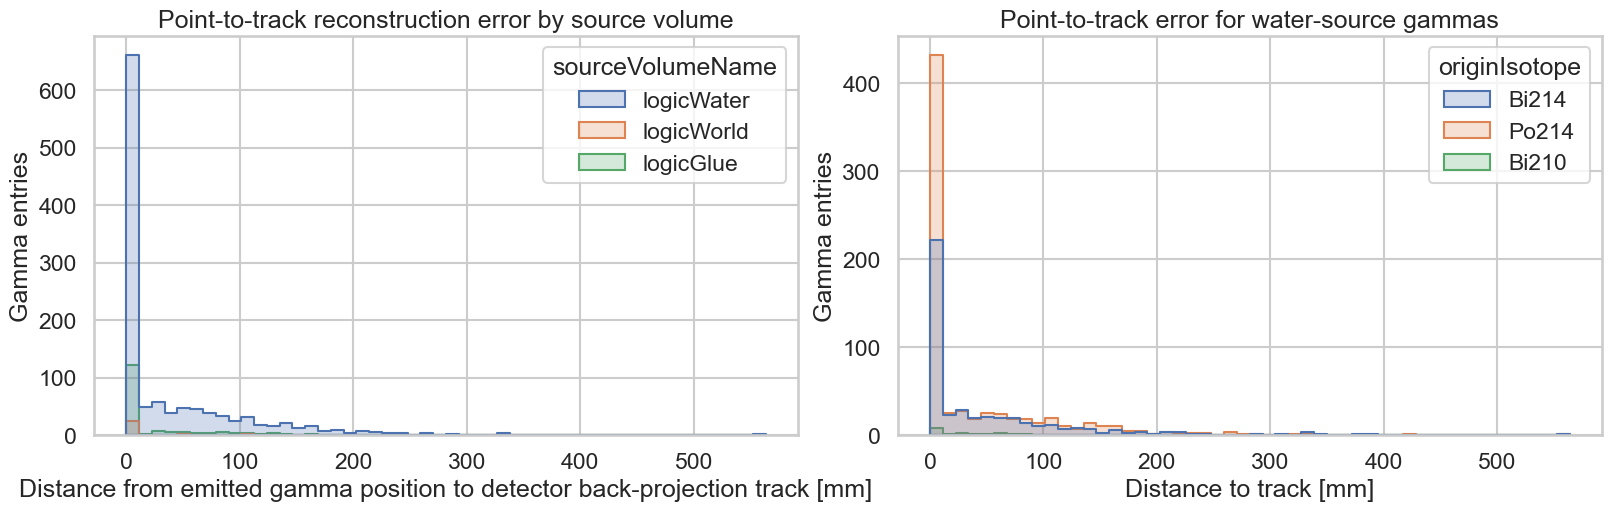

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.histplot(
    reco_truth_df,
    x='point_to_track_error_mm',
    hue='sourceVolumeName',
    bins=50,
    element='step',
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title('Point-to-track reconstruction error by source volume')
axes[0].set_xlabel('Distance from emitted gamma position to detector back-projection track [mm]')
axes[0].set_ylabel('Gamma entries')

sns.histplot(
    reco_truth_df[reco_truth_df['sourceVolumeName'] == 'logicWater'],
    x='point_to_track_error_mm',
    hue='originIsotope',
    bins=50,
    element='step',
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title('Point-to-track error for water-source gammas')
axes[1].set_xlabel('Distance to track [mm]')
axes[1].set_ylabel('Gamma entries')
plt.show()


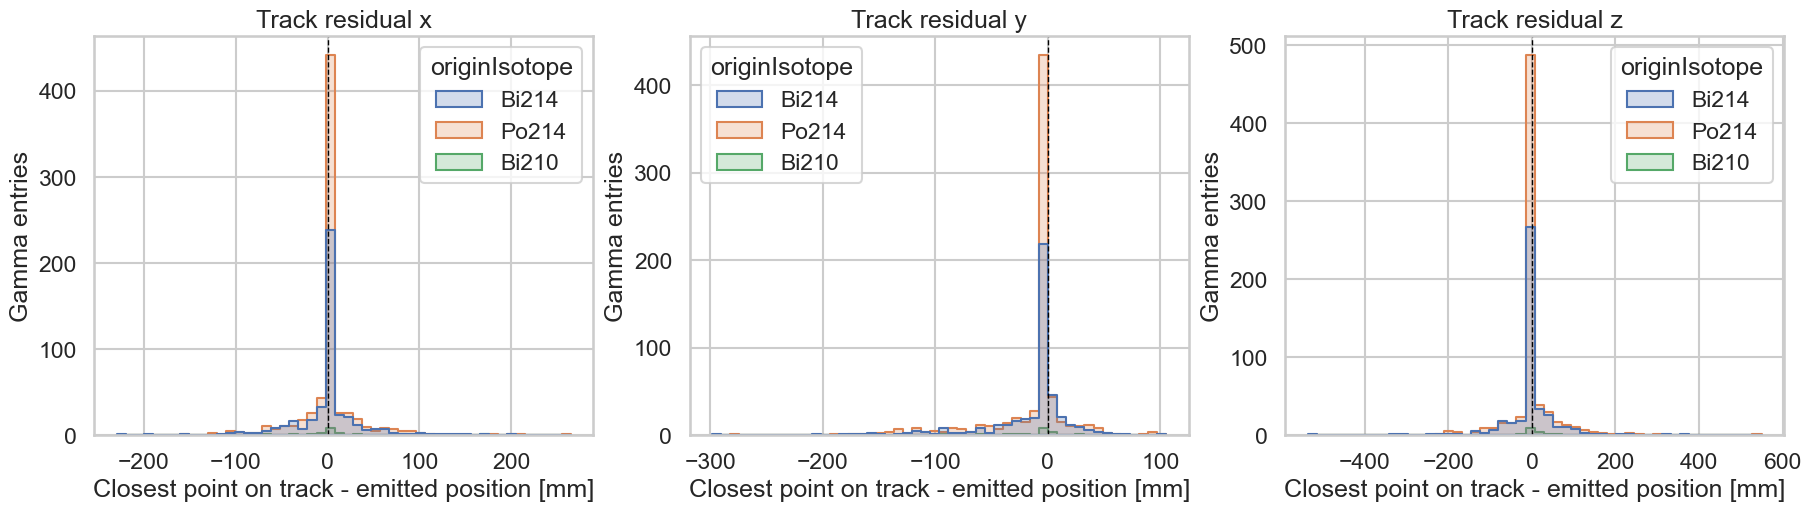

In [12]:

residual_plot_df = reco_truth_df[reco_truth_df['sourceVolumeName'] == 'logicWater'].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, residual_col, title in zip(
    axes,
    ['track_residual_x_mm', 'track_residual_y_mm', 'track_residual_z_mm'],
    ['Track residual x', 'Track residual y', 'Track residual z'],
):
    sns.histplot(
        residual_plot_df,
        x=residual_col,
        hue='originIsotope',
        bins=50,
        element='step',
        common_norm=False,
        ax=ax,
    )
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Closest point on track - emitted position [mm]')
    ax.set_ylabel('Gamma entries')
plt.show()


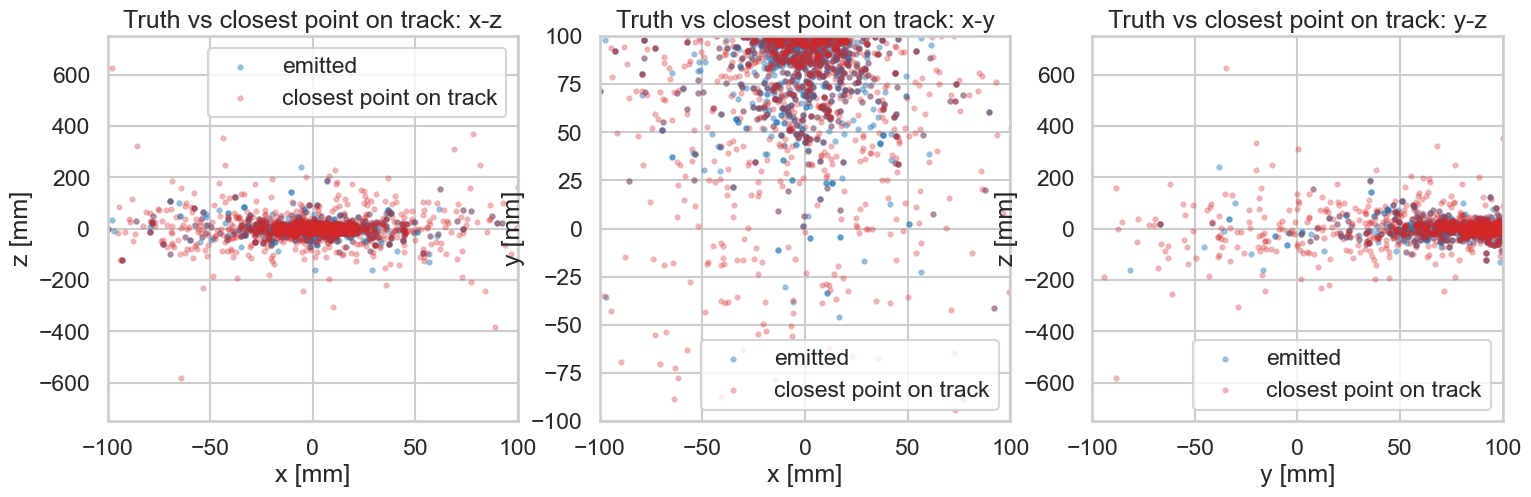

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=False)
truth_projection_specs = [
    ('emitX_mm', 'emitZ_mm', 'closest_track_x_mm', 'closest_track_z_mm', (-x_water_half_mm, x_water_half_mm), (-z_water_half_mm, z_water_half_mm), 'x [mm]', 'z [mm]', 'Truth vs closest point on track: x-z'),
    ('emitX_mm', 'emitY_mm', 'closest_track_x_mm', 'closest_track_y_mm', (-x_water_half_mm, x_water_half_mm), (-y_water_half_mm, y_water_half_mm), 'x [mm]', 'y [mm]', 'Truth vs closest point on track: x-y'),
    ('emitY_mm', 'emitZ_mm', 'closest_track_y_mm', 'closest_track_z_mm', (-y_water_half_mm, y_water_half_mm), (-z_water_half_mm, z_water_half_mm), 'y [mm]', 'z [mm]', 'Truth vs closest point on track: y-z'),
]

plot_df = reco_truth_df[reco_truth_df['sourceVolumeName'] == 'logicWater'].copy()
for ax, (truth_x, truth_y, closest_x, closest_y, xlim, ylim, xlabel, ylabel, title) in zip(axes, truth_projection_specs):
    ax.scatter(plot_df[truth_x], plot_df[truth_y], s=10, alpha=0.35, label='emitted', color='#1f77b4')
    ax.scatter(plot_df[closest_x], plot_df[closest_y], s=10, alpha=0.25, label='closest point on track', color='#d62728')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.show()